# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint


## Learning Objectives

At the end of the experiment, you will be able to:

* load and pre-process data from text file
* load and use a pre-trained tokenizer
* finetune a GPT-2 language model from Hugging Face's `transformers` library
* push the finetuned model to HuggingFace model hub
* load the finetuned model from hub for inference

## Dataset Description

The text data file is taken from The International Gita Society's eBook named "***BHAGAVAD-GITA*** Author: Sage Veda Vyasa", Translated in English by Ramananda Prasad, refer [here](https://www.gita-society.com/Read-bhagavad-gita.html).

It contains:

* the concept of duty and the moral implications of one's actions

* the importance of performing one's duty without attachment to the results

* various teachings, including the importance of performing one's duty according to one's station in life, the nature of the self, and the ultimate purpose of life

* guidance on how to live a righteous life, manage one's emotions, and make ethical decisions

* insights into achieving spiritual enlightenment and understanding one's true nature beyond the physical body

The text data is inside **`document.pdf`** and will be downloaded once the below setup cells are executed.

### **GPT-2**

In recent years, the OpenAI GPT-2 exhibited an impressive ability to write coherent and passionate essays that exceeded what current language models can produce. The GPT-2 wasn't a particularly novel architecture - its architecture is very similar to the **decoder-only transformer**. The GPT2 was, however, a very large, transformer-based language model trained on a massive dataset.

Here, we are going to fine-tune the GPT2 model with the text of International Gita Society's eBook - BHAGAVAD-GITA. We can expect that the model will be able to reply to the prompt related to the subject matter of this book after fine-tuning.

To know more about GPT-2, refer [here](http://jalammar.github.io/illustrated-gpt2/).

### Installing Dependencies

In [1]:
%%capture
if False:

  # For loading models, tokenizers, and datasets from HuggingFace
  !pip -q uninstall pyarrow -y
  !pip -q install pyarrow==15.0.2
  !pip -q install datasets
  !pip -q install accelerate
  !pip -q install transformers

  # For reading text from PDF files
  !pip -q install PyPDF2

In [2]:

if False:
  import os
  !pip uninstall numpy pandas datasets torch transformers PyPDF2 -y
  !pip install numpy>=2.0
  !pip install pandas==2.2.2 datasets==2.20.0 torch==2.4.1 transformers==4.44.2 PyPDF2==3.0.1
  os.kill(os.getpid(), 9)  # Forces a full restart of the runtime

### <font color="#990000">Restart Session/Runtime</font>

### Setup Steps:

In [3]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "2500856" #@param {type:"string"}

In [4]:
#@title Please enter your password (normally your phone number) to continue: { run: "auto", display-mode: "form" }
password = "9845104125" #@param {type:"string"}

##### After creating a copy of the notebook, follow the instructions below based on your batch:

* PG Batch: Run the below cell as it is.

* AC (Advanced) Batch: Follow the steps below to avoid execution errors.

1. Click on “Show Code” under the cell labeled:
    “Run this cell to complete the setup for this Notebook.”

2. Refer to the attached snippet and locate the red-highlighted section.

4. Add the following code snippet under the “Show Code” section, ensuring that the correct cohort ID is used in place of the example shown below:

           "batch": "IIITH-AC-AIML-26"  

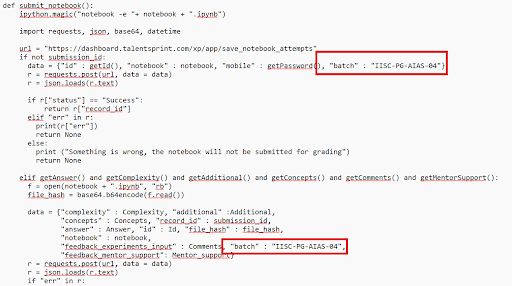

In [5]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
import re
ipython = get_ipython()

notebook= "U4W20_66_Finetune_GPT2_A" #name of the notebook

def setup():
#  ipython.magic("sx pip3 install torch")
    from IPython.display import HTML, display
    ipython.magic("sx wget https://drive.google.com/uc?id=12jYBY0yqwNEErkqol06BtEQF3C-wSUBS -O document.pdf")
    display(HTML('<script src="https://dashboard.talentsprint.com/aiml/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(),"batch": "IIITH-PG-AIML-26"}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print(r["err"])
        return None
      else:
        print ("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getWalkthrough() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook, "feedback_walkthrough":Walkthrough ,
              "feedback_experiments_input" : Comments,
              "feedback_inclass_mentor": Mentor_support,
              "batch": "IIITH-PG-AIML-26"}

      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


def getWalkthrough():
  try:
    if not Walkthrough:
      raise NameError
    else:
      return Walkthrough
  except NameError:
    print ("Please answer Walkthrough Question")
    return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")



Setup completed successfully


### Importing required packages

In [6]:
import os
import re
import PyPDF2
import torch
from datasets import load_dataset
from transformers import GPT2Tokenizer, GPT2LMHeadModel, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

import warnings
warnings.filterwarnings('ignore')

### Load the data

The data is in a PDF file (.pdf)

Create function to read pdf file:

In [7]:
# Function to read document pdf files

def read_pdf(pdf_path):
    text = ""

    # Open the PDF file
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)

        # Iterate over each page
        for page_num in range(len(reader.pages)):
            if page_num > 3:                         # extract text starting from page 5
                page = reader.pages[page_num]
                text += page.extract_text()

    return text


In [8]:
# Read files/documents

pdf_path = 'document.pdf'
# YOUR CODE HERE to read text using file path
text_file = read_pdf(pdf_path)

In [9]:
print(text_file[:8000])

 
  
 
BHAGAVAD -GITA in ENGLISH  
Author: Sage Veda Vy asa 
Translat ed in English : Ramananda Prasad , Ph.D.  
Language Editor s: Needed  
Contact: rprasad@gita -society.com  
***** 
“Let noble thoughts come to us from everywhere”    
(The Vedas)  
 
INTRODUCTION  
The Bhagavad -Gita is a doctrine of universal truth  and a book 
of moral and spiritual growth . Its message is sublime and non -sec-
tarian . It deals with the most sacred metaphysi cal science. It im-
parts the knowledge of the Self and answers two universal ques-
tions: Who am I, and how can I lead a happy and peaceful life in 
this wor d full of dualities  and dilemmas ?  
It's a timeless book of wisdom  that inspired Thoreau, Emerson, 
Einstein, Oppenheimer, Gandhi and many others. The Bhagavad -
Gita teaches us how  to equip ourselves  for the battle of life. A re-
peated study with faith purifies our psyche and guides us to face 
the challenges of modern livin g leading to inner peace and happi-
ness.  
Gita teaches

### Pre-processing

- Remove any excess newline characters from the text
- Remove any excess spaces
- Remove unnecessary words (Header & Page number)
- Keep 100 words per line inside text

In [10]:
# Remove excess newline characters
#text_file.replace("\n\n", "\n").replace("  "," ")
text_file = re.sub(r'\n+', '\n', text_file).strip()
# YOUR CODE HERE

In [11]:
# Remove excess spaces
text_file = re.sub(r' +', ' ', text_file).strip()
# YOUR CODE HERE

In [12]:
# Remove unnecessary words (Header & Page number)
text_file = re.sub(r' \d+ International Gita Society', '', text_file)
text_file = re.sub(r' Bhagavad -Gita \d+', '', text_file)

In [13]:
print(text_file[:8000])

BHAGAVAD -GITA in ENGLISH 
Author: Sage Veda Vy asa 
Translat ed in English : Ramananda Prasad , Ph.D. 
Language Editor s: Needed 
Contact: rprasad@gita -society.com 
***** 
“Let noble thoughts come to us from everywhere” 
(The Vedas) 
 
INTRODUCTION 
The Bhagavad -Gita is a doctrine of universal truth and a book 
of moral and spiritual growth . Its message is sublime and non -sec-
tarian . It deals with the most sacred metaphysi cal science. It im-
parts the knowledge of the Self and answers two universal ques-
tions: Who am I, and how can I lead a happy and peaceful life in 
this wor d full of dualities and dilemmas ? 
It's a timeless book of wisdom that inspired Thoreau, Emerson, 
Einstein, Oppenheimer, Gandhi and many others. The Bhagavad -
Gita teaches us how to equip ourselves for the battle of life. A re-
peated study with faith purifies our psyche and guides us to face 
the challenges of modern livin g leading to inner peace and happi-
ness. 
Gita teaches the spiritual science 

- Keep 100 words per line inside text

In [14]:
new_text_file = ''
word_list = []
# YOUR CODE HERE... to code the logic to keep 100 words per line from 'text_file' and save it in 'new_text_file'
for line in text_file.split('\n'):
    words = line.split()
    for word in words:
      word_list.append(word)
      if len(word_list) == 100:
        new_text_file += " ".join(word_list)+'\n'
        word_list = []


if word_list:
  new_text_file += " ".join(word_list)+'\n'


In [15]:
len(new_text_file)

129766

In [16]:
print(new_text_file[:8000])

BHAGAVAD -GITA in ENGLISH Author: Sage Veda Vy asa Translat ed in English : Ramananda Prasad , Ph.D. Language Editor s: Needed Contact: rprasad@gita -society.com ***** “Let noble thoughts come to us from everywhere” (The Vedas) INTRODUCTION The Bhagavad -Gita is a doctrine of universal truth and a book of moral and spiritual growth . Its message is sublime and non -sec- tarian . It deals with the most sacred metaphysi cal science. It im- parts the knowledge of the Self and answers two universal ques- tions: Who am I, and how can I lead a happy and peaceful life
in this wor d full of dualities and dilemmas ? It's a timeless book of wisdom that inspired Thoreau, Emerson, Einstein, Oppenheimer, Gandhi and many others. The Bhagavad - Gita teaches us how to equip ourselves for the battle of life. A re- peated study with faith purifies our psyche and guides us to face the challenges of modern livin g leading to inner peace and happi- ness. Gita teaches the spiritual science of Self -realizat

In [17]:
len(new_text_file.split('\n')[0].split())

100

### Split the text into training and validation sets

In [18]:
# Split the text into training and validation sets

train_fraction = 0.8
split_index = int(train_fraction * len(new_text_file))

train_text = new_text_file[:split_index]

# YOUR CODE HERE to get remaining text_file content
val_text = new_text_file[split_index:]

In [19]:
len(train_text)

103812

In [20]:
# Save the training and validation data as text files

with open("train.txt", "w") as f:
    f.write(train_text)

# YOUR CODE HERE to save 'val_text' data into a text file 'val.txt'
with open("val.txt", "w") as f:
    f.write(val_text)

### Load pre-trained tokenizer - GP2Tokenizer

The GPT2Tokenizer is based on ***Byte-Pair-Encoding***.

Byte-Pair Encoding (BPE) was initially developed as an algorithm to compress texts, and then used by OpenAI for tokenization when pretraining the GPT model.

In BPE, new tokens are added until the desired vocabulary size is reached by learning ***merges***, which are rules to merge two elements of the existing vocabulary together into a new one.

Below figure shows how the vocabulary updates as the BPE algorithm progresses.

<br>
<center>
<img src="https://cdn.iisc.talentsprint.com/AIandMLOps/Images/Byte-pair-encoding.png" width=450px>
</center>

To know more about Byte-Pair Encoding, refer [here](https://huggingface.co/learn/nlp-course/chapter6/5?fw=pt#byte-pair-encoding-tokenization).

<br>

Some of the parameters required to create a GP2Tokenizer includes:

- ***vocab_file (str):*** path to the vocabulary json file; maps token to integer ids

- ***merges_file (str):*** path to the ***merges*** file; contains the merge rule; The merge rule file should have one merge rule per line. Every merge rule contains merge entities separated by a space.



Here, we will instantiate a GPT-2 tokenizer from a predefined tokenizer using `from_pretrained()` method.

It includes a parameter:

- ***pretrained_model_name_or_path:*** It can be a string of a predefined tokenizer hosted inside a model repo on huggingface.co.

    For example: *gpt2, gpt2-medium, gpt2-large, or gpt2-xl*

    This will download the corresponding vocab, merges, and config files.

In [87]:
# Set up the tokenizer
checkpoint_small = 'gpt2'
checkpoint_large = 'gpt2-large'
checkpoint_medium = 'gpt2-medium'
checkpoint_extra_large = 'gpt2-xl'
checkpoint = checkpoint_small
# YOUR CODE HERE to load GPT2Tokenizer using 'checkpoint'           # also try gpt2, gpt2-large and gpt2-medium, also gpt2-xl
tokenizer = GPT2Tokenizer.from_pretrained(checkpoint)

# set pad_token_id to unk_token_id
tokenizer.pad_token = tokenizer.unk_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

In [88]:
# Tokenize sample text using GP2Tokenizer
sample_ids = tokenizer("Hello world")
sample_ids

{'input_ids': [15496, 995], 'attention_mask': [1, 1]}

In [89]:
# Generate tokens for sample text
sample_tokens = tokenizer.convert_ids_to_tokens(sample_ids['input_ids'])
sample_tokens

['Hello', 'Ġworld']

In [90]:
# Generate original text back
tokenizer.convert_tokens_to_string(sample_tokens)

'Hello world'

### Tokenize text data

In [91]:
from datasets import load_dataset

In [92]:
train_file_path = 'train.txt'
val_file_path = 'val.txt'

dataset = load_dataset("text", data_files={"train": train_file_path,
                                           "validation": val_file_path})

In [93]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 185
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 46
    })
})

In [94]:
dataset['train']['text'][0]

'BHAGAVAD -GITA in ENGLISH Author: Sage Veda Vy asa Translat ed in English : Ramananda Prasad , Ph.D. Language Editor s: Needed Contact: rprasad@gita -society.com ***** “Let noble thoughts come to us from everywhere” (The Vedas) INTRODUCTION The Bhagavad -Gita is a doctrine of universal truth and a book of moral and spiritual growth . Its message is sublime and non -sec- tarian . It deals with the most sacred metaphysi cal science. It im- parts the knowledge of the Self and answers two universal ques- tions: Who am I, and how can I lead a happy and peaceful life'

In [95]:
block_size = 256     # max tokens in an input sample

def tokenize_function(examples):
    return tokenizer(examples["text"], padding='max_length', truncation=True, max_length=block_size, return_tensors='pt')

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/185 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

In [96]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask'],
        num_rows: 185
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask'],
        num_rows: 46
    })
})

In [97]:
len(tokenized_datasets['train']['input_ids'][0])

256

In [98]:
tokenizer.decode(tokenized_datasets['train']['input_ids'][0])

'BHAGAVAD -GITA in ENGLISH Author: Sage Veda Vy asa Translat ed in English : Ramananda Prasad, Ph.D. Language Editor s: Needed Contact: rprasad@gita -society.com ***** “Let noble thoughts come to us from everywhere” (The Vedas) INTRODUCTION The Bhagavad -Gita is a doctrine of universal truth and a book of moral and spiritual growth. Its message is sublime and non -sec- tarian. It deals with the most sacred metaphysi cal science. It im- parts the knowledge of the Self and answers two universal ques- tions: Who am I, and how can I lead a happy and peaceful life<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endo

### Data Collator

Data collators are objects that:

- will form a batch by using a list of dataset elements as input
- may apply some processing (like padding)

One of the data collators, `DataCollatorForLanguageModeling`, can also apply some random data augmentation (like random masking) on the formed batch.

<br>

`DataCollatorForLanguageModeling` is a data collator used for language modeling. Inputs are dynamically padded to the maximum length of a batch if they are not all of the same length.

Parameters:

- ***tokenizer:*** The tokenizer used for encoding the data.
- ***mlm*** (bool, optional, default=True): Whether or not to use masked language modeling.
    - If set to False, the labels are the same as the inputs with the padding tokens ignored (by setting them to -100).
    - Otherwise, the labels are -100 for non-masked tokens and the value to predict for the masked token.
- ***return_tensors*** (str): The type of Tensor to return. Allowable values are “np”, “pt” and “tf” for numpy array, pytorch tensor, and tensorflow tensor respectively.

To know more about `DataCollatorForLanguageModeling` parameters, refer [here](https://huggingface.co/docs/transformers/v4.32.0/en/main_classes/data_collator#transformers.DataCollatorForLanguageModeling).

In [99]:
# Create a Data collator object
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False, return_tensors="pt")

### Load pre-trained Model

***GPT2LMHeadModel*** is the GPT2 Model transformer with a language modeling head on top (linear layer with weights tied to the input embeddings).

This model is a PyTorch `torch.nn.Module` subclass which can be used as a regular PyTorch Module.

Parameters:

- ***config (GPT2Config):*** Model configuration class with all the parameters of the model. Initializing with a config file does not load the weights associated with the model, only the configuration.

Here, we will instantiate a pretrained pytorch model from a pre-trained model configuration, using `from_pretrained()` method, that will load the weights associated with the model.

In [100]:
# Set up the model
# YOUR CODE HERE to load GPT2LMHeadModel using 'checkpoint'             # also try gpt2, gpt2-large and gpt2-medium, also gpt2-xl
model = GPT2LMHeadModel.from_pretrained(checkpoint)

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

**Note: The training time for different GPT models with GPU for this dataset are as follows:**

* **GPT-2 : ~25 minutes for 100 epochs**

* **GPT-2 Medium:  ~1 hour for 100 epochs**

* **GPT-2 Large : Run out of memory**

### Fine-tune Model *(Switch to GPU runtime if needed)*

Train a GPT-2 model using the provided training arguments. Save the resulting trained model and tokenizer to a specified output directory.

The `Trainer` class provides an API for feature-complete training in PyTorch for most standard use cases.

Before instantiating your Trainer, create a `TrainingArguments` to access all the points of customization during training.

`TrainingArguments` parameters:

- ***output_dir*** (str): The output directory where the model predictions and checkpoints will be written.
- ***overwrite_output_dir*** (bool, optional, default=False): If True, overwrite the content of the output directory. Use this to continue training if output_dir points to a checkpoint directory.
- ***per_device_train_batch_size*** (int, optional, default=8): The batch size per GPU/TPU/MPS/NPU core/CPU for training.
- ***per_device_eval_batch_size*** (int, optional, default=8): The batch size per GPU/TPU/MPS/NPU core/CPU for evaluation.
- ***save_total_limit*** (int, optional): If a value is passed, will limit the total amount of checkpoints. Deletes the older checkpoints in output_dir.

To know more about `TrainingArguments` parameters, refer [here](https://huggingface.co/docs/transformers/v4.32.0/en/main_classes/trainer#transformers.TrainingArguments).

To know more about `Trainer` parameters, refer [here](https://huggingface.co/docs/transformers/v4.32.0/en/main_classes/trainer#transformers.Trainer).

In [101]:
# Set up the training arguments

model_output_path = "/content/gpt2_model_medium"

training_args = TrainingArguments(
                output_dir = model_output_path,
                overwrite_output_dir = True,
                num_train_epochs = 100,
                per_device_train_batch_size = 4,
                per_device_eval_batch_size = 4,
                save_steps = 1_000,
                save_total_limit = 2,
                logging_dir = './logs')

# YOUR CODE HERE to create TrainingArguments object with
                    # model_output_path as output directory,
                    # overwrite the content of output directory,
                    # use 4 as batch size per device for training and evaluation,
                    # num_train_epochs = 100,
                    # save_steps = 1_000,
                    # save_total_limit = 2,
                    # logging_dir = './logs')

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [102]:
# Train the model
trainer = Trainer(model = model,
                  args= training_args,
                  data_collator = data_collator,
                  train_dataset = tokenized_datasets['train'],
                  eval_dataset = tokenized_datasets['validation'])
# YOUR CODE HERE to create Trainer object with
                # model = model,
                # args = training_args,
                # data_collator = data_collator,
                # train_dataset = train_dataset,
                # eval_dataset = val_dataset)

OutOfMemoryError: CUDA out of memory. Tried to allocate 198.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 9.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.24 GiB is allocated by PyTorch, and 182.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [85]:
# Disabling Weights and Biases logging
import os
os.environ["WANDB_DISABLED"] = "true"

In [86]:
trainer.train()

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 9.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.24 GiB is allocated by PyTorch, and 182.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [40]:
# Save the model
saved_model_path = "/content/finetuned_gpt2_large_model"
trainer.save_model(saved_model_path)

# Save the tokenizer
tokenizer.save_pretrained(saved_model_path)
# YOUR CODE HERE to save 'tokenizer' using save_pretrained() method at path model_output_path

('/content/finetuned_gpt2_model/tokenizer_config.json',
 '/content/finetuned_gpt2_model/special_tokens_map.json',
 '/content/finetuned_gpt2_model/vocab.json',
 '/content/finetuned_gpt2_model/merges.txt',
 '/content/finetuned_gpt2_model/added_tokens.json')

### Test Model with user input prompts

##### Now, let us test the model with some prompt


The `generate_response()` function takes a trained *model*, *tokenizer*, and a *prompt* string as input and generates a response using the GPT-2 model.

In [41]:
def generate_response(model, tokenizer, prompt, max_length=200):

    input_ids = tokenizer.encode(prompt, return_tensors="pt")      # 'pt' for returning pytorch tensor

    # Check the device of the model
    device = next(model.parameters()).device

    # Move input_ids to the same device as the model
    input_ids = input_ids.to(device)

    # Create the attention mask and pad token id
    attention_mask = torch.ones_like(input_ids)
    pad_token_id = tokenizer.eos_token_id

    output = model.generate(
        input_ids,
        max_length=max_length,
        num_return_sequences=1,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [42]:
# Load the fine-tuned model and tokenizer

# YOUR CODE HERE to load model from saved_model_path
my_model = GPT2LMHeadModel.from_pretrained(saved_model_path)
# YOUR CODE HERE to load tokenizer from saved_model_path
my_tokenizer = GPT2Tokenizer.from_pretrained(saved_model_path)

In [43]:
# Testing

prompt = "How can one live a righteous life?"           # Replace with your desired prompt
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response

Generated response:


'How can one live a righteous life? (4.31) The Supreme Lord said: One who considers the path of Self - knowledge and the path of selfless service as different from each other, and who considers the path of nonviolence as the same, really does not know Me. (4.32) Many have also stated that they do not know Me, their lives, or even in their lives, really do not matter. What matters is who they serve Me with an unwavering mind, O Arjuna. (4.33) Do they not belong to Me because I am the highest of all. I am the ultimate, the sustainer, the king, the ocean among the stars, and the Lord of all the universe. (4.34) I am the source of all light, O Arjuna. I am the goal of all, and the enjoyer of all. I am the bondage of all. I am the origin of all beings. I am'

In [44]:
# Testing

prompt = "What is the purpose of life?"           # Replace with your desired prompt
# YOUR CODE HERE
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response


Generated response:


'What is the purpose of life? How can I lead a happy and peaceful life? How can I defeat the evil of birth and death? (4.31) Two basic paths of departure after death O Arjuna, now I shall describe different paths departing by which, after death, the yogis do or do not come back. (4.32) Pass- ing gradually, a fter death, through celestial controllers of fire, light, daytime, the bright lunar fortnight, and the six months of the north- ern solstice of the sun, yogis who know the Self attain supreme abode and do not come back to earth. (4.33) Passing gradually, after death, through celestial controllers of light, daytime, the bright lunar fortnight, and the six months of the north- ern solstice of the sun, yogis who know the Self attain supreme abode and do not come back to earth. (4.34) Passing gradually, after death'

In [45]:
# Testing
prompt = "What is Karma?"          # Replace with your desired prompt
# YOUR CODE HERE
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response


Generated response:


'What is Karma? How does Karma work? How can You be remembered at the time o f death by those who have control over the times? (8.01) The Supreme Lord said: O Arjuna, list en once again to remember Me, O Arjuna, because I have said this many times. (8.02) Just as a happy person puts on new garments after discarding the old ones; similarly, the living entity acquires new bodies af ter casting away the old bodies. (8.03) The purpose of incarnation of God The Supreme Lord said: O Arjuna, list en once again to remember Me, because I am eternal and omnipresent. (8.04) My incarnation is the beginning, the middle, and the end of all creation, O Arjuna. The Supreme Lord said: I shall briefly explain to you My prominent divine manifestations because My manifestations are endless. (8.05) O Arjuna, I shall briefly'

In [46]:
# Testing
prompt = "How to overcome dilemma or fear?"          # Replace with your desired prompt
# YOUR CODE HERE
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response


Generated response:


'How to overcome dilemma or fear? (4.01 -02) The yogi who sees the same eternal Supreme Lord dwelling as Spirit equally within all mortal beings, should not be confused, indeed, about what is right and what is wrong. (4.03) One should not become confused by seeing inaction in seeing inaction; there is no sin in seeing inaction. (4.04) When the Lord does not see, who is to be helped, and when the Lord does not see, what is the su- preme knowledge, O Arjuna? (4.05) The yogi who sees inaction in the beginning, the middle, and the end, is not confused about what is right and what is wrong with this particular knowledge. (4.06) When the Lord does not see, who is to be helped, and when the Lord does not see, what is the su- preme knowledge, O Arjuna? (4.07) When the Lord'

In [47]:
# Testing
prompt = "How to control emotions during tough times?"          # Replace with your desired prompt
# YOUR CODE HERE
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response


Generated response:


'How to control emotions during tough times? How to develop a personality that is steady, in- tellect, and free from passion and anger? How to develop a tranquil person, O Arjuna, that is not agitated by anger or greed. (6.01 -02) The seven basic qualities of an enlightened person An enlightened person — by perceiving the Lord as the enjoyer, the noble as the lower, and the wicked as the other — sees every being with an equal eye. (6.03) One who is endowed with all these qualities is a person of subdued mind. Ignored by greed, greed, and delusion, a person of subdued mind — by selfless service — attains God. (6.04) Self -knowledge arises from the experience of sense objects O Arjuna, the senses are said to be the supreme refuge of living entity. Reasoning is said to be the friend of the wise. Spirit is said to be the friend of the ignorant'

In [48]:
# Testing
prompt = "Is there a way to achieve enlightenment?"          # Replace with your desired prompt
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response


Generated response:


'Is there a way to achieve enlightenment? (4.31) The Supreme Lord said: There is no spiritual discipline or austerities of the ascetics. Therefore, you should not perform any action that would create any great disturbance in the society. (4.32) Perform your obligatory duty because working is indeed better than sitting idle. Even the maintena nce of your body would be impossible without work. (4.33) Human beings are bound by work. Therefore, you should not disturb the mind of the wise whose knowledge is imperfect. (4.34) Human beings are bound by work, but the urge for work is indestructible. Therefore, you should not disturb the mind of the unsuc- cessful, whose knowledge is imperfect. (4.35) Work is not the cause of death For those who are not united with the Lord, then death is the inevitable consequence of action. (4.36) Death is the ultimate result of sin The'

In [49]:
# Testing
prompt = "Why did Brutus kill Simon?"          # Replace with your desired prompt
response = generate_response(model, tokenizer, prompt)
print("Generated response:")
response

Generated response:


'Why did Brutus kill Simon? Who is the Simonetta among the mortal warriors? Who is the Conqueror? Who is the Gunas of the Himalaya? Who is the Lord of the Vyas? How can a person of firm resolve be freed from the bondage of Karma? How can the world be freed from the trap of Karma by a person of unself-realization? (8.01 -02) The Supreme Lord said: The warriors of the world are deluded by the illusive power of Karma; therefore, they do not know the Self. They are confused, and confused by inaction become agai n. (8.03) When the Self -knowledge is absent from the senses, it is better for the one who eats the bread of Self -knowledge to know the Supreme Being by eating the pure, just food. (8.04) When the senses are absent, one attains the Supreme Being. The one who eats the pure, just food,'

In the case of the GPT-2 tokenizer, the model uses a byte-pair encoding (BPE) algorithm, which tokenizes text into subword units. As a result, one word might be represented by multiple tokens.

For example, if you set max_length to 50, the generated response will be limited to 50 tokens, which could be fewer than 50 words, depending on the text.

## Push your fine-tuned model to HuggingFace Model Hub

**Steps to push your fine-tuned model to HuggingFace Model Hub**

1. [Sign up](https://huggingface.co/join) for a Hugging Face account
2. Create an access token for your account and save it
3. Store your access token in the Hugging Face cache folder within colab
4. Push your fine-tuned model and tokenizer to Model Hub
5. Load the model back from Hub and test it with user input prompts

* **Create an access token for your account**

    Once you have an account, to create an access token:
    
    - Go to your `Settings`, then click on the `Access Tokens` tab. Click on the `New token` button to create a new User Access Token.
    - Select a Token type as `Write` and give a name for your token
    - Click on Create token
    - Once a token is created save it somewhere
    - When required later, use the old saved token or create a new token again

    To know more about Access Tokens, refer [here](https://huggingface.co/docs/hub/security-tokens).

* **Store your access token in the Hugging Face cache folder within colab**

    Once you have your User Access Token, run the following command to authenticate your identity to the Hub.
    - `!huggingface-cli login`
    - Paste your Access token when prompted
    - Type **n** when prompted to Add token as git credential? (Y/n)

    For more details on login, refer [here](https://huggingface.co/docs/huggingface_hub/quick-start#login).

In [50]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
The token `AIML_26` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/h

* **Push your fine-tuned model and tokenizer to Model Hub**

    - Use `push_to_hub()` method of your model and tokenizer both, to push them on hub
    - Specify name for your repository where the model and tokenizer will be pushed using `repo_id` parameter
    - Push model and tokenizer to the same repository

        - Use `push_to_hub()` method of your model. For parameter details, refer [here](https://huggingface.co/docs/transformers/main_classes/model#transformers.PreTrainedModel.push_to_hub).
        - Use `push_to_hub()` method of your tokenizer. For parameter details, refer [here](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.push_to_hub).
        - Access your pushed model at `https://huggingface.co/[YOUR-USER-NAME]/[YOUR-MODEL-REPO-NAME]/tree/main`

In [54]:
# Push model
my_repo = "gita-text-generation-gpt2"
model.push_to_hub(repo_id= my_repo, commit_message= "Upload fine-tuned model")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...314l_0g/model.safetensors:   8%|8         | 40.0MB /  498MB            

CommitInfo(commit_url='https://huggingface.co/tarantripathi/gita-text-generation-gpt2/commit/3d4a353f73771acf9fcccb8cbfea88b17612e62f', commit_message='Upload fine-tuned model', commit_description='', oid='3d4a353f73771acf9fcccb8cbfea88b17612e62f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tarantripathi/gita-text-generation-gpt2', endpoint='https://huggingface.co', repo_type='model', repo_id='tarantripathi/gita-text-generation-gpt2'), pr_revision=None, pr_num=None)

In [55]:
# Push tokenizer
tokenizer.push_to_hub(repo_id= my_repo, commit_message= "Upload tokenizer used")

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/tarantripathi/gita-text-generation-gpt2/commit/be9c88541f36c1df24381ca79561d18019653ee5', commit_message='Upload tokenizer used', commit_description='', oid='be9c88541f36c1df24381ca79561d18019653ee5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tarantripathi/gita-text-generation-gpt2', endpoint='https://huggingface.co', repo_type='model', repo_id='tarantripathi/gita-text-generation-gpt2'), pr_revision=None, pr_num=None)

Access your pushed model at `https://huggingface.co/[YOUR-USER-NAME]/[YOUR-MODEL-REPO-NAME]/tree/main`

For example: https://huggingface.co/sumanthk/gita-text-generation-gpt2/tree/main

* **Load the model and tokenizer back from Hub and test it with user input prompts**

    - In many cases, the architecture you want to use can be guessed from the name or the path of the pretrained model you are supplying to the `from_pretrained()` method. **AutoClasses** can be used to automatically retrieve the relevant model given the name/path to the pretrained weights/config/vocabulary.

    - Instantiating one of `AutoConfig`, `AutoModel`, and `AutoTokenizer` will directly create a class of the relevant architecture.

    - When the GPT2 Model transformer has a language modeling head on top, you can use an auto class with language modeling head on top as well - `AutoModelWithLMHead`.

    - Specify full path of your model repo i.e. ***''YOUR-USER-NAME/YOUR-REPO-NAME''*** while calling `from_pretrained()` method.

In [56]:
from transformers import AutoModelWithLMHead, AutoTokenizer

In [57]:
#username = "sumanthk"      # change it to your HuggingFace username
username = "tarantripathi"      # change it to your HuggingFace username
my_repo = "gita-text-generation-gpt2"
my_checkpoint = username + '/' + my_repo       # eg. "sumanthk/gita-text-generation-gpt2"
my_checkpoint

'tarantripathi/gita-text-generation-gpt2'

In [58]:
# Load your model from hub
loaded_model = AutoModelWithLMHead.from_pretrained(my_checkpoint)

config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

In [59]:
# Load your tokenizer from hub
loaded_tokenizer = AutoTokenizer.from_pretrained(my_checkpoint)

tokenizer_config.json:   0%|          | 0.00/525 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/470 [00:00<?, ?B/s]

In [60]:
# Testing

prompt = "How can one live a righteous life?"           # Replace with your desired prompt
response = generate_response(loaded_model, loaded_tokenizer, prompt)
print("Generated response:")
response

Generated response:


'How can one live a righteous life? (2.31) The wise, who truly under- stand Me as the Supreme Being, know everything and worship Me wholeheartedly, O Arjuna. (2.32) Thus, I have explained this most secret science of Self -knowledge, O sinless Arjuna. Having under- stood this, one becomes enlightened; o ne’s all duties are accom- plished; and the goal of human life is achieved, O Arjuna. (2.33) CHAPTER 3 3. Divine and the demonic qualities A list of divine qualities t o be cultivated The Supreme Lord said: Fearlessness, purity of the inner psy- che, persev erance in the yoga of Self - knowledge, persev erance in the study of the Vedas, and righteous action in the battlefield. (3.01) Fearlessness is said to be the best of all the divine qualities. It is said to'

### Please answer the questions below to complete the experiment:




In [61]:
#@title The architecture of GPT is very similar to: { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "the decoder-only transformer" #@param ["", "the encoder-only transformer", "the decoder-only transformer", "the encoder-decoder transformer", "none of the above"]

In [62]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "Good and Challenging for me" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [63]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "the training arguments, training and data massaging, still not adept with it. That was the difficulty. Hugging face interfacing is also bit new" #@param {type:"string"}


In [64]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "Yes" #@param ["","Yes", "No"]


In [65]:
#@title  Experiment walkthrough video? { run: "auto", vertical-output: true, display-mode: "form" }
Walkthrough = "Didn't use" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [66]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [67]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [68]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

Your submission is successful.
Ref Id: 13975
Date of submission:  19 Apr 2026
Time of submission:  07:31:21
View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions
